# Intro to Options Straddles and Strangles

In this notebook, we discuss definitions of straddle and strangle strategies.

These strategies are basically a way to trade on the volatility of the underlying asset. 

For example, let's assume that I believe that a certain underlying asset will be very volatile over a period of time, but I do not know for certain if its price will increase or decrease (I only expect it to change significantly). This can happen, for example, if a big event is approachig, for example, an earnings call, or the release of a new product. One way in which I could try to take advantage of such high volatility would be to buy a call and a put option with the same expiration date and same strike price $K$. If, at maturity, the price of the underlying asset is larger than $K$, our put is worthless, but our call is not. On the other hand, if the spot price at maturity is below $K$, the call is worthless, but not the put. 

Let's visualize what this looks like.

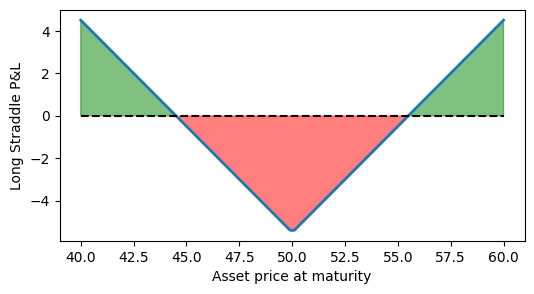

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Let's initialize the price of the options
call_price = 3
put_price = 2.5

# Specify the strike price
strike = 50

# Now, consider a range of possible prices at maturity
maturity_spot = np.linspace(40, 60, 100)

# Compute the values of the options at maturity
call_value = np.where(maturity_spot <= strike, 0, maturity_spot - strike)
put_value = np.where(maturity_spot >= strike, 0, strike - maturity_spot)
breakeven = np.zeros_like(maturity_spot)

# Compute the valuation of a straddle portfolio
straddle_value = call_value + put_value

# To compute P&L, remember we had to buy these options
pnl = straddle_value - (call_price + put_price)

# Plot
fig, axes = plt.subplots(figsize=(6, 3))
axes.set_xlabel('Asset price at maturity')
axes.set_ylabel('Long Straddle P&L')
axes.plot(maturity_spot, pnl, linewidth=2)
axes.plot(maturity_spot, breakeven, color='black', linestyle='--')
axes.fill_between(maturity_spot, breakeven, pnl, where=(pnl > breakeven), color='green', alpha=0.5)
_ = axes.fill_between(maturity_spot, breakeven, pnl, where=(pnl < breakeven), color='red', alpha=0.5)

In a long straddle like the one above, as long as the price swings enough to offset the initial cost of acquiring the options, the profit we can make is unbounded. 

Let's now consider a different situation. Let's say I believe the price of the underlying asset will not change too much, but perhaps I wish to allow for some greater "wiggle" room than with a short straddle. One way to do so is to short a put option with strike price $K_p$ and short a call option with strike price $K_c$, such that $K_p < K_c$. Let's see what that looks like.

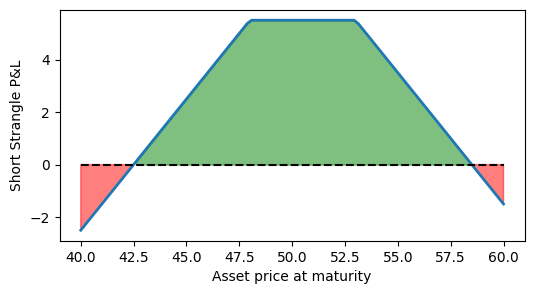

In [2]:
# Now, we need to consider two different strike prices
put_strike = 48
call_strike = 53

# Once again, compute the values of the options at maturity
call_value = np.where(maturity_spot <= call_strike, 0, maturity_spot - call_strike)
put_value = np.where(maturity_spot >= put_strike, 0, put_strike - maturity_spot)

# Compute the value of this strangle
strangle_value = call_value + put_value

# Assemble our portfolio, remembering that we sold these options in the beginning
pnl = (call_price + put_price) - strangle_value

# Plot
fig, axes = plt.subplots(figsize=(6, 3))
axes.set_xlabel('Asset price at maturity')
axes.set_ylabel('Short Strangle P&L')
axes.plot(maturity_spot, pnl, linewidth=2)
axes.plot(maturity_spot, breakeven, color='black', linestyle='--')
axes.fill_between(maturity_spot, breakeven, pnl, where=(pnl > breakeven), color='green', alpha=0.5)
_ = axes.fill_between(maturity_spot, breakeven, pnl, where=(pnl < breakeven), color='red', alpha=0.5)

Here, we see that, as long as the price does not move much, we make a profit, as the put and call options we sold are worthless, or near worthless. However, if the price deviates too much, the potential for losses is unbounded. 